In [1]:
import sys
from pathlib import Path 
import pickle
import random

HW = 3
N = 9
M = 20
K = 81
INF = 10**18
MOD = 998244353
ONLINE_JUDGE = True if len(sys.argv) >= 2 and sys.argv[1] == "ONLINE_JUDGE" else False

def fastcopy(obj):
    return pickle.loads(pickle.dumps(obj, -1))

def debug_print(*args, **kwargs):
    if not ONLINE_JUDGE:
        print(*args, **kwargs)

In [2]:
class Env:
    def __init__(self, input_txt_path: Path):
        self.grid, self.stamps = self._input(input_txt_path)

    def _input(self, txt_path):
        with open(txt_path, mode="r") as file:
            lines = file.readlines()
        grid = []
        for i in range(1, 1+N):
            d = list(map(int, lines[i].split()))
            grid.append(d)
        stamps = []
        for i in range(1+N, 1+N+M*HW, 3):
            tmp_stamp = []
            for j in range(HW):
                d = list(map(int, lines[i+j].split()))
                tmp_stamp.append(d)
            stamps.append(tmp_stamp)
        return grid, stamps

    def print_grid(self):
        for d in self.grid:
            print(d)
    
    def pring_stamps(self):
        for s in self.stamps:
            for d in s:
                print(d)
            print()

In [3]:
def evaluate_score(grid: list[list[int]]) -> int:
    s = 0
    for h in range(N):
        for w in range(N):
            s += grid[h][w] % MOD
    return s

In [4]:
def step(grid: list[list[int]], stamps):
    score = evaluate_score(grid)
    ans = None
    for m1 in range(M):
        for h1 in range(N-3):
            for w1 in range(N-3):
                now_grid = fastcopy(grid)
                for h in range(HW):
                    for w in range(HW):
                        now_grid[h1+h][w1+w] = (now_grid[h1+h][w1+w] + stamps[m1][h][w]) % MOD
                tmp_score = evaluate_score(now_grid)
                if tmp_score > score:
                    score = tmp_score
                    ans = (m1, h1, w1)
    return ans

In [5]:
def random_step():
    rand_m = random.randint(0, M-1)
    rand_h = random.randint(0, N-3)
    rand_w = random.randint(0, N-3)
    return rand_m, rand_h, rand_w

In [6]:
def simulate(env: Env, random_k):
    ans_list = []
    now_grid = fastcopy(env.grid)
    for k in range(random_k):
        ans = random_step()
        ans_list.append(ans)
        m1, h1, w1 = ans
        for h in range(HW):
            for w in range(HW):
                now_grid[h1+h][w1+w] += env.stamps[m1][h][w]

    for k in range(K-random_k):
        ans = step(now_grid, env.stamps)
        if ans is None:
            debug_print("None", k)
            break
        ans_list.append(ans)
        m1, h1, w1 = ans
        for h in range(HW):
            for w in range(HW):
                now_grid[h1+h][w1+w] += env.stamps[m1][h][w]
    
    score = evaluate_score(now_grid)

    return ans_list, score

In [7]:
SIMULATE_NUM = 30
def solve(env: Env):
    max_score = 0
    max_ans_list = []
    for simulate_n in range(SIMULATE_NUM):
        if simulate_n == 0:
            random_k = 0
        else:
            random_k = 50
        ans_list, score = simulate(env, random_k)
        if score > max_score:
            max_score = score
            max_ans_list = ans_list
    return max_ans_list, max_score

In [8]:
TEST_CASE_NUM = 100
scores = []
for i in range(TEST_CASE_NUM):
    debug_print(f"----- {i}/100 -----")
    input_txt_path = Path(f"./in/{str(i).zfill(4)}.txt")
    env = Env(input_txt_path)
    ans_list, score = solve(env)
    score = score / 10 ** 10
    print(score)
    scores.append(score)

----- 0/100 -----
None 12
None 9
None 14
None 18
None 8
None 14
None 11
None 21
None 11
None 15
None 13
None 19
None 13
None 12
None 13
None 14
None 12
None 14
None 16
None 12
None 18
None 14
None 15
None 10
None 15
None 18
None 13
None 22
None 14
None 22
6.0702174968
----- 1/100 -----
None 15
None 13
None 10
None 16
None 11
None 13
None 12
None 12
None 11
None 11
None 13
None 14
None 9
None 12
None 12
None 11
None 13
None 11
None 12
None 9
None 16
None 13
None 9
None 12
None 13
None 12
None 12
None 14
None 13
None 14
6.0737238882
----- 2/100 -----
None 13
None 17
None 18
None 14
None 18
None 14
None 15
None 25
None 13
None 14
None 10
None 16
None 19
None 22
None 18
None 21
None 16
None 13
None 21
None 11
None 13
None 15
None 21
None 22
None 10
None 10
None 15
None 15
None 12
None 17
6.0938000206
----- 3/100 -----
None 13
None 13
None 15
None 18
None 11
None 13
None 12
None 19
None 16
None 15
None 15
None 17
None 13
None 20
None 11
None 16
None 14
None 12
None 12
None 12
None 23
None 1

In [9]:
ave_score = sum(scores) / len(scores)
ave_score

6.123967108805998

In [10]:
ave_score * 150

918.5950663208997

<BarContainer object of 100 artists>

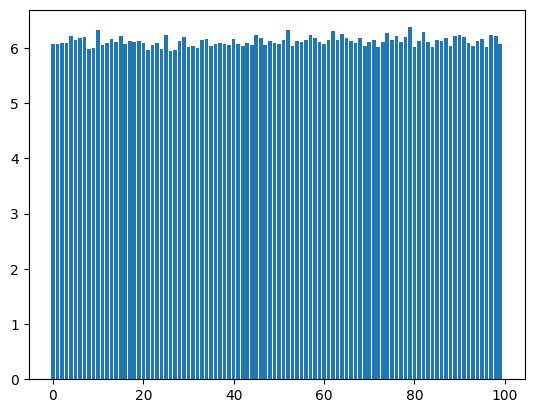

In [11]:
import matplotlib.pyplot as plt
plt.bar(range(TEST_CASE_NUM), scores)

In [12]:
M * 6 * 6 * 81 * 81

4723920